# Retail Sales Dataset — Exploratory Data Analysis (EDA)

**Objective:** Perform a thorough exploratory data analysis on a retail sales dataset to uncover sales patterns, customer behaviour trends, and actionable business insights.

**Tech stack:** Python, Pandas, Matplotlib, Seaborn, Jupyter Notebook.

### Business questions
1. What does the dataset look like and is it suitable for analysis?
2. What are the sales and revenue trends over time?
3. Which product categories generate the most revenue and sales volume?
4. How do purchasing patterns differ by gender and age?
5. What factors are most strongly associated with transaction value?
6. What recommendations can management take from the findings?


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

df = pd.read_csv("retail_sales_dataset.csv")
df.head()


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


## 1. Data Understanding and Quality Check

In [19]:
print("Shape:", df.shape)
print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isnull().sum().to_frame("missing_values"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nUnique values:")
display(df.nunique().to_frame("unique_values"))

print("\nDescriptive statistics (mean, std, min, quartiles, max):")
display(df.describe(include="all").T)

print("\nMode of each numerical column:")
numeric_cols_preview = ["Age", "Quantity", "Price per Unit", "Total Amount"]
display(df[numeric_cols_preview].mode().iloc[0].to_frame("mode"))

Shape: (1000, 9)

Data types:


,dtype
Transaction ID,int64
Date,str
Customer ID,str
Gender,str
Age,int64
Product Category,str
Quantity,int64
Price per Unit,int64
Total Amount,int64



Missing values:


,missing_values
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0



Duplicate rows: 0

Unique values:


,unique_values
Transaction ID,1000
Date,345
Customer ID,1000
Gender,2
Age,47
Product Category,3
Quantity,4
Price per Unit,5
Total Amount,18



Descriptive statistics (mean, std, min, quartiles, max):


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Transaction ID,1000.0,NaN,NaN,NaN,500.5,288.819436,1.0,250.75,500.5,750.25,1000.0
Date,1000,345,2023-05-16,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,1000,1000,CUST001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,1000,2,Female,510,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,1000.0,NaN,NaN,NaN,41.392,13.68143,18.0,29.0,42.0,53.0,64.0
Product Category,1000,3,Clothing,351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,1000.0,NaN,NaN,NaN,2.514,1.132734,1.0,1.0,3.0,4.0,4.0
Price per Unit,1000.0,NaN,NaN,NaN,179.89,189.681356,25.0,30.0,50.0,300.0,500.0
Total Amount,1000.0,NaN,NaN,NaN,456.0,559.997632,25.0,60.0,135.0,900.0,2000.0



Mode of each numerical column:


,mode
Age,43.0
Quantity,4.0
Price per Unit,50.0
Total Amount,50.0


### Data preparation

The `Date` column is converted to datetime and additional time features are created for trend analysis. Revenue is represented by `Total Amount`.


In [20]:
df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()
df["Quarter"] = df["Date"].dt.to_period("Q").astype(str)
df["Day_of_Week"] = df["Date"].dt.day_name()

df["Calculated Amount"] = df["Quantity"] * df["Price per Unit"]

print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())
print("Revenue:", df["Total Amount"].sum())
print("Average transaction value:", df["Total Amount"].mean())

# Check whether Total Amount agrees with Quantity × Price per Unit
print("Rows where Total Amount differs from Quantity × Price per Unit:",
      (df["Total Amount"] != df["Calculated Amount"]).sum())


Date range: 2023-01-01 to 2024-01-01
Revenue: 456000
Average transaction value: 456.0
Rows where Total Amount differs from Quantity × Price per Unit: 0


**Observation:** No missing values, no duplicates, 1,000 rows total, so the data doesn't
need cleaning. I also checked that `Total Amount` actually equals `Quantity × Price per
Unit` for every row, and it does, so the revenue numbers can be trusted. The mode values
(Age 43, Quantity 4, Price/Total 50) don't line up with the mean, and the median for
`Total Amount` is way below the mean — so most transactions are on the cheaper side, with
a few big ones pulling the average up.

## 2. Descriptive Statistics
Mean, median, mode, and standard deviation for all numerical columns.

In [21]:
numeric_cols = ["Age", "Quantity", "Price per Unit", "Total Amount"]

desc = df[numeric_cols].agg(["mean", "median", "std"]).T
desc["mode"] = df[numeric_cols].mode().iloc[0]
desc = desc[["mean", "median", "mode", "std"]]
desc.round(2)

,mean,median,mode,std
Age,41.39,42.0,43.0,13.68
Quantity,2.51,3.0,4.0,1.13
Price per Unit,179.89,50.0,50.0,189.68
Total Amount,456.00,135.0,50.0,560.00


**Observation:** Average order value (`Total Amount`) is about \$456, but the median
(\$135) is far lower than the mean, which signals a right-skewed distribution — most
transactions are modest, with a smaller number of large, high-value purchases pulling the
average up. The average customer age is in their early 40s. `Quantity` and `Price per Unit`
both have moderate spread, consistent with a mix of cheap, high-volume items and pricier,
low-volume ones.

## Univariate Analysis

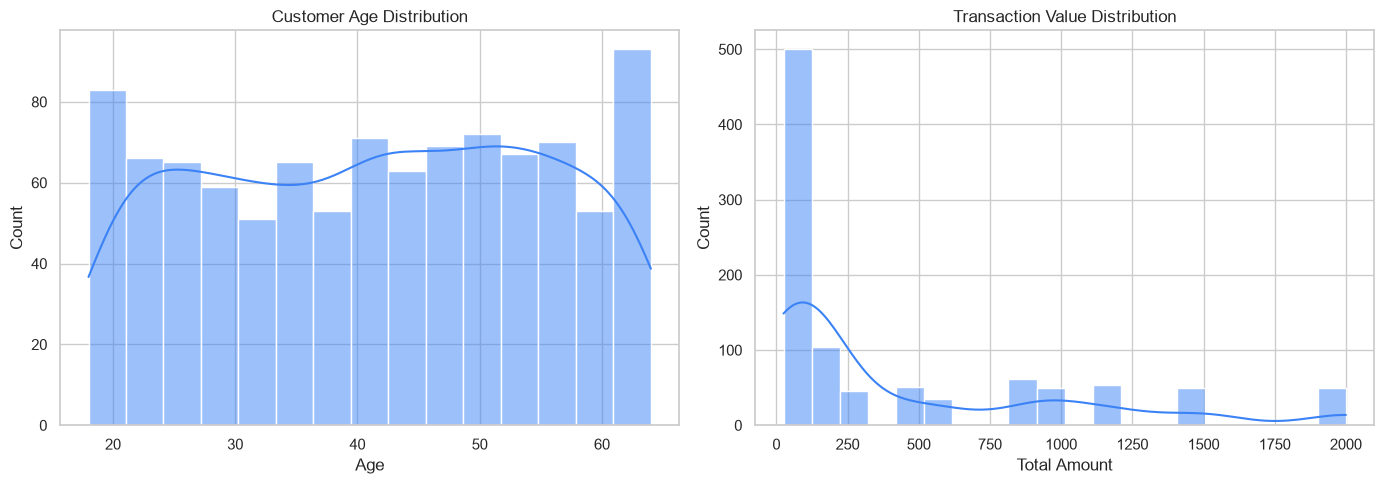

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["Age"], bins=15, kde=True, ax=axes[0], color="#3b82f6")
axes[0].set_title("Customer Age Distribution")

sns.histplot(df["Total Amount"], bins=20, kde=True, ax=axes[1], color="#3b82f6")
axes[1].set_title("Transaction Value Distribution")

plt.tight_layout()
plt.show()


**Observation:** Ages are spread out pretty evenly, no big cluster anywhere. `Total
Amount` is skewed right like I said above — lots of smaller transactions, a handful of
big ones.

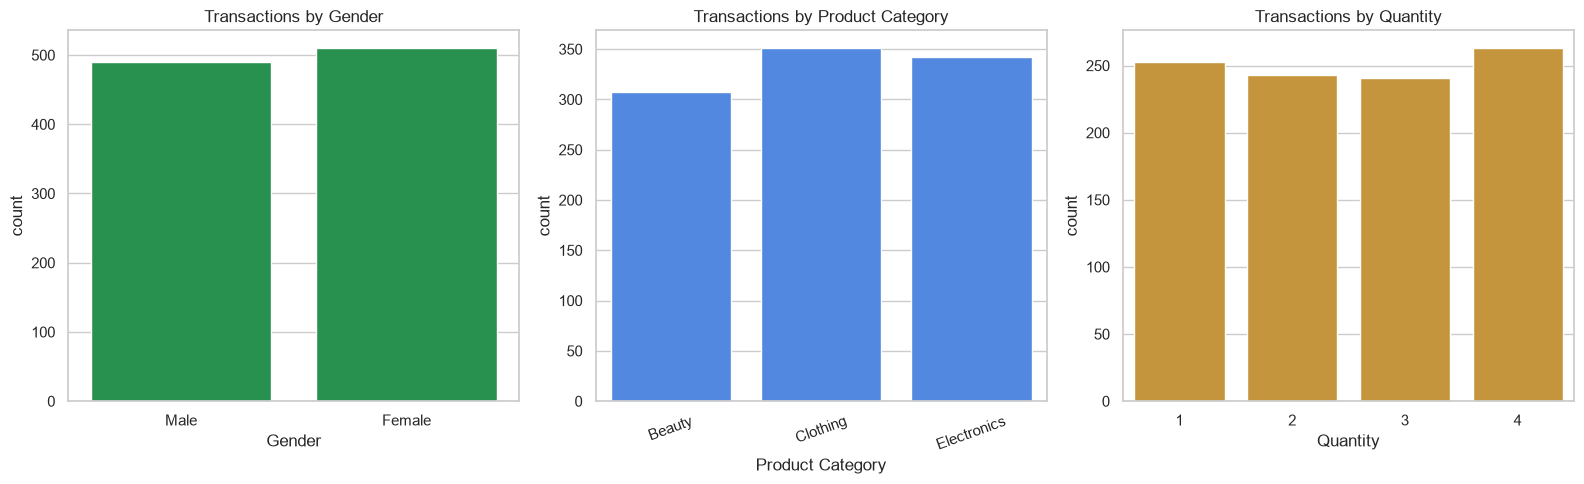

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.countplot(data=df, x="Gender", ax=axes[0], color="#16a34a")
axes[0].set_title("Transactions by Gender")

sns.countplot(data=df, x="Product Category", ax=axes[1], color="#3b82f6")
axes[1].set_title("Transactions by Product Category")
axes[1].tick_params(axis="x", rotation=20)

sns.countplot(data=df, x="Quantity", ax=axes[2], color="#dc9c26")
axes[2].set_title("Transactions by Quantity")

plt.tight_layout()
plt.show()


**Observation:** Gender and category counts are close to even (Female 510 / Male 490,
Clothing 351 / Electronics 342 / Beauty 307). Quantity per transaction is also spread out
across 1-4, nothing stands out as the "typical" order size.

## 3. Time-Series Analysis

,Date,Revenue,Transactions,Quantity
0,2023-01-01,35450,76,195
1,2023-02-01,44060,85,214
2,2023-03-01,28990,73,194
3,2023-04-01,33870,86,214
4,2023-05-01,53150,105,259
5,2023-06-01,36715,77,197
6,2023-07-01,35465,72,176
7,2023-08-01,36960,94,227
8,2023-09-01,23620,65,170
9,2023-10-01,46580,96,252


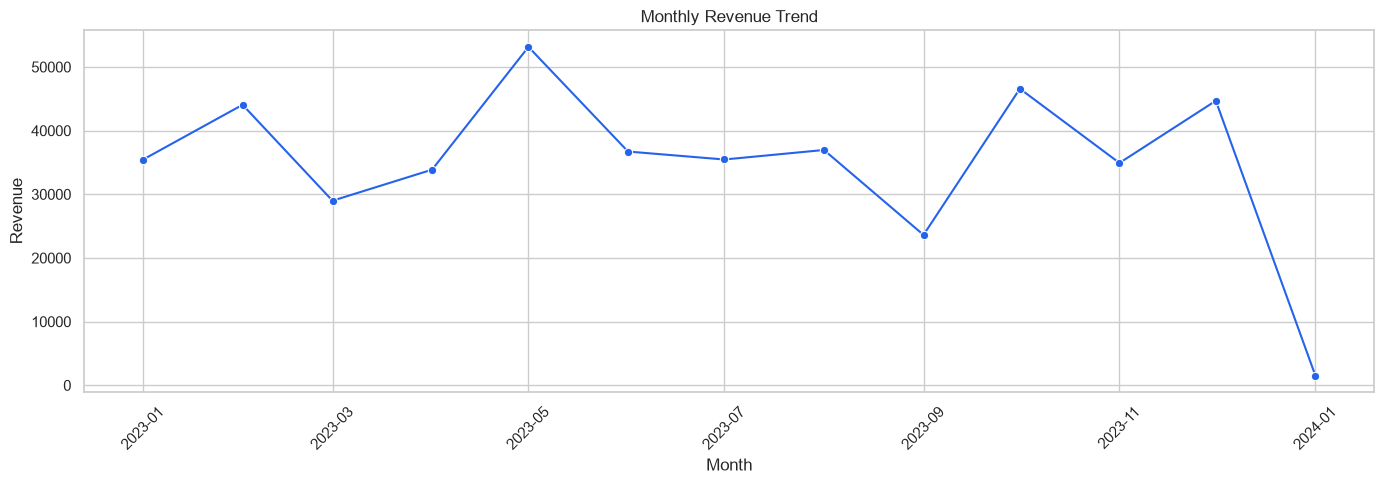

In [24]:
## Monthly Revenue Trend
monthly = (
    df.groupby(df["Date"].dt.to_period("M"))
      .agg(Revenue=("Total Amount", "sum"),
           Transactions=("Transaction ID", "count"),
           Quantity=("Quantity", "sum"))
      .reset_index()
)
monthly["Date"] = monthly["Date"].dt.to_timestamp()

display(monthly)

plt.figure(figsize=(14, 5))
sns.lineplot(data=monthly, x="Date", y="Revenue", marker="o", color="#2563eb")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Observation:** Revenue by month is pretty up and down, not a clear trend. May 2023 is
the highest month (\$53,150), September 2023 is the lowest (\$23,620). The Jan 2024 point
is only 2 transactions so I'm not counting that as a real drop.

,Quarter,Revenue,Transactions
0,2023Q1,108500,234
1,2023Q2,123735,268
2,2023Q3,96045,231
3,2023Q4,126190,265
4,2024Q1,1530,2


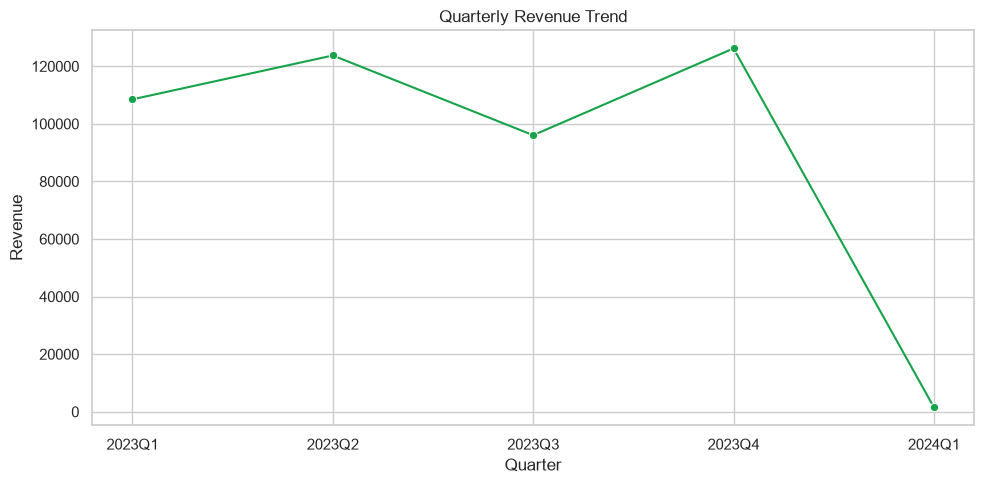

In [25]:
## Quarterly Revenue Trend
quarterly = (
    df.groupby("Quarter")
      .agg(Revenue=("Total Amount", "sum"),
           Transactions=("Transaction ID", "count"))
      .reset_index()
)

display(quarterly)

plt.figure(figsize=(10, 5))
sns.lineplot(data=quarterly, x="Quarter", y="Revenue", marker="o", color="#16a34a")
plt.title("Quarterly Revenue Trend")
plt.xlabel("Quarter")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

**Observation:** Looking at it by quarter instead, Q2 and Q4 are the strongest
(\$123,735 and \$126,190), Q1 and Q3 the weakest (\$108,500 and \$96,045). Not a huge gap
between them though (~24%), so I wouldn't call this a strong seasonal pattern — just one
year of data isn't really enough to say for sure.

## 4. Product Category Analysis

,Transactions,Units_Sold,Revenue,Avg_Transaction
Product Category,,,,
Electronics,342,849,156905,458.786550
Clothing,351,894,155580,443.247863
Beauty,307,771,143515,467.475570


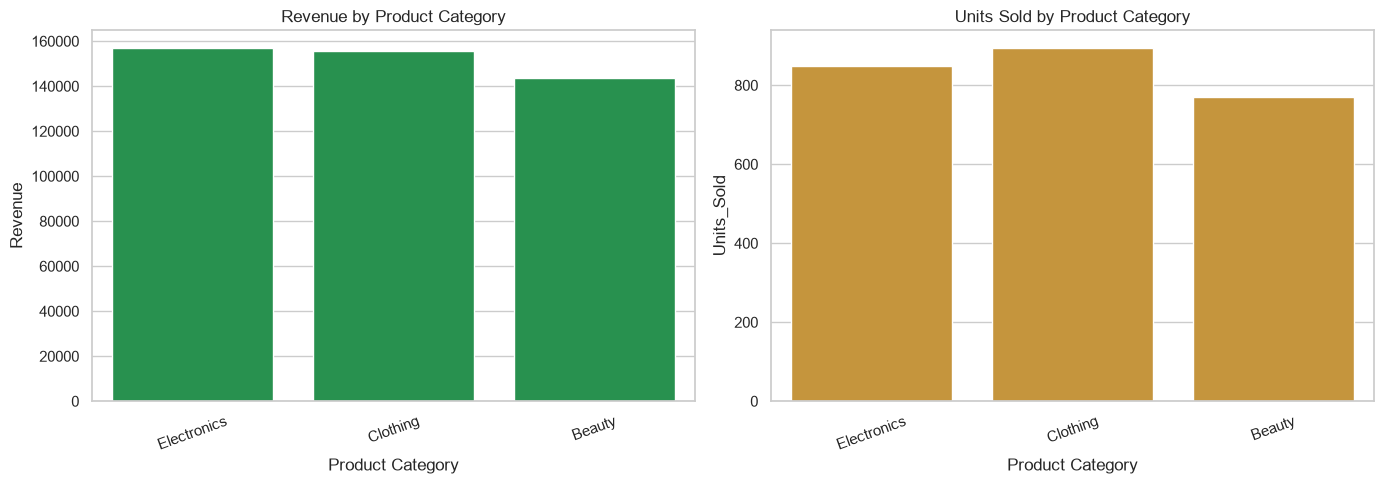

In [26]:
category = (
    df.groupby("Product Category")
      .agg(
          Transactions=("Transaction ID", "count"),
          Units_Sold=("Quantity", "sum"),
          Revenue=("Total Amount", "sum"),
          Avg_Transaction=("Total Amount", "mean")
      )
      .sort_values("Revenue", ascending=False)
)

display(category)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=category.reset_index(), x="Product Category", y="Revenue", ax=axes[0], color="#16a34a")
axes[0].set_title("Revenue by Product Category")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=category.reset_index(), x="Product Category", y="Units_Sold", ax=axes[1], color="#dc9c26")
axes[1].set_title("Units Sold by Product Category")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


**Observation:** All three categories are close in revenue — Electronics slightly
ahead (\$156,905), then Clothing (\$155,580), then Beauty (\$143,515). Beauty has the
fewest transactions but the highest average order value (\$467), so people spend more per
purchase in Beauty even though they buy it less often.

**Note:** the dataset only has `Product Category`, not individual product names, so I
couldn't do an actual top-10-products ranking — I used category totals instead since
that's the closest thing available.

## 5. Customer Behaviour Analysis

,Transactions,Units_Sold,Revenue,Avg_Transaction
Gender,,,,
Female,510,1298,232840,456.549020
Male,490,1216,223160,455.428571


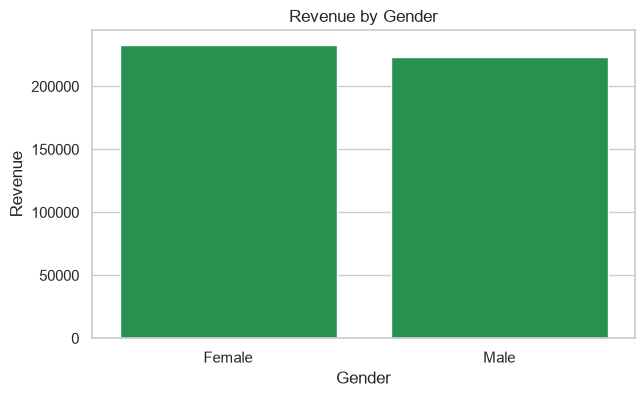

In [27]:
gender_summary = (
    df.groupby("Gender")
      .agg(
          Transactions=("Transaction ID", "count"),
          Units_Sold=("Quantity", "sum"),
          Revenue=("Total Amount", "sum"),
          Avg_Transaction=("Total Amount", "mean")
      )
)

display(gender_summary)

plt.figure(figsize=(7, 4))
sns.barplot(data=gender_summary.reset_index(), x="Gender", y="Revenue", color="#16a34a")
plt.title("Revenue by Gender")
plt.ylabel("Revenue")
plt.show()


**Observation:** Revenue and average spend are basically the same across gender
(Female \$232,840 / Male \$223,160, averages within \$1 of each other). Gender doesn't
seem to matter much for spending in this data.

,Transactions,Revenue,Avg_Transaction,Units_Sold
Age_Group,,,,
18–24,149,74650,501.006711,366
25–34,203,97090,478.275862,522
35–44,207,96835,467.801932,533
45–54,225,97235,432.155556,578
55–64,216,90190,417.546296,515


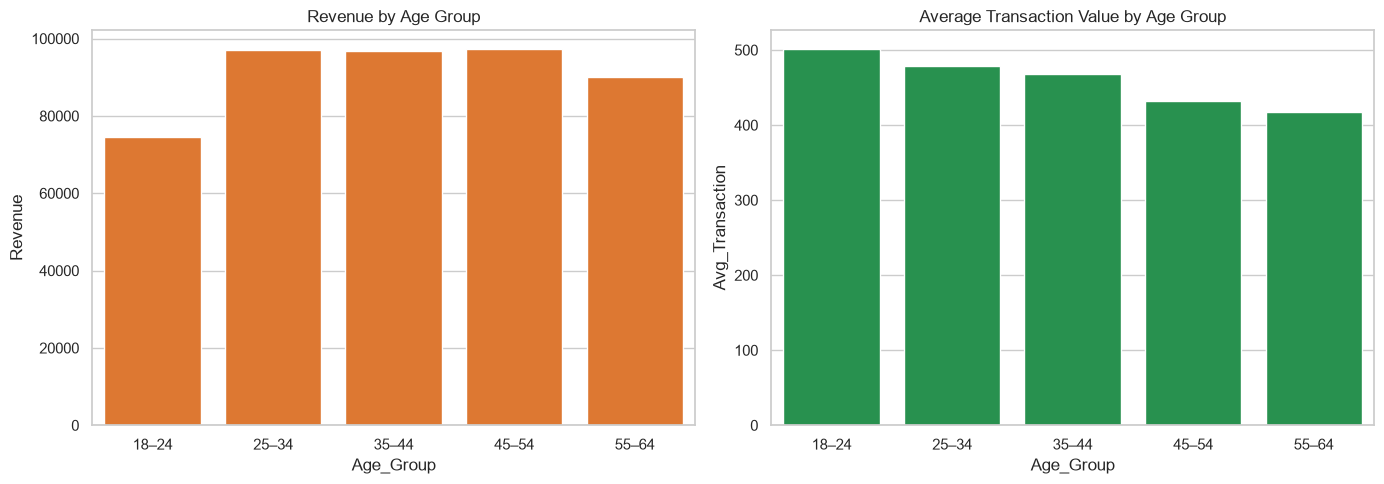

In [28]:
bins = [17, 24, 34, 44, 54, 64]
labels = ["18–24", "25–34", "35–44", "45–54", "55–64"]

df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels, include_lowest=True)

age_summary = (
    df.groupby("Age_Group", observed=False)
      .agg(
          Transactions=("Transaction ID", "count"),
          Revenue=("Total Amount", "sum"),
          Avg_Transaction=("Total Amount", "mean"),
          Units_Sold=("Quantity", "sum")
      )
)

display(age_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=age_summary.reset_index(), x="Age_Group", y="Revenue", ax=axes[0], color="#f97316")
axes[0].set_title("Revenue by Age Group")

sns.barplot(data=age_summary.reset_index(), x="Age_Group", y="Avg_Transaction", ax=axes[1], color="#16a34a")
axes[1].set_title("Average Transaction Value by Age Group")

plt.tight_layout()
plt.show()


**Observation:** Total revenue is highest in the middle age brackets (25-34 and
45-54), but average spend per transaction actually goes down as age goes up — 18-24 has
the highest average (\$501), 55-64 the lowest (\$417.55). So younger customers buy less
often but spend more each time; older customers buy a bit more often but spend less per
purchase.

## 6. Product × Gender Analysis

,Product Category,Gender,Revenue,Transactions
0,Beauty,Female,74830,166
1,Beauty,Male,68685,141
2,Clothing,Female,81275,174
3,Clothing,Male,74305,177
4,Electronics,Female,76735,170
5,Electronics,Male,80170,172


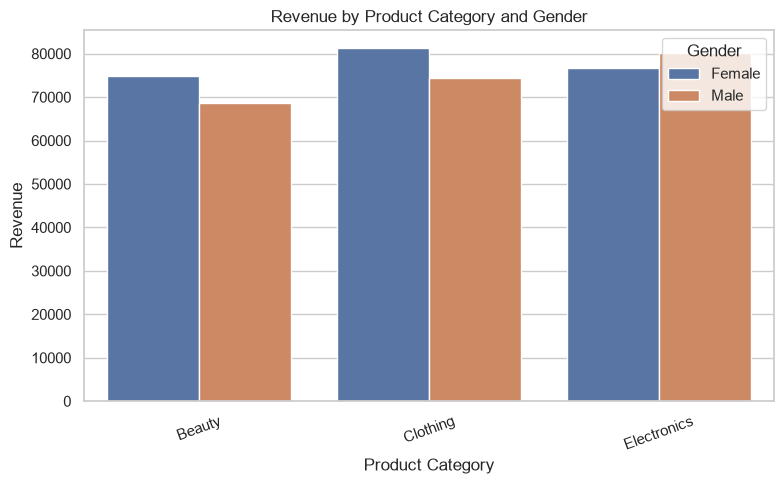

In [29]:
category_gender = (
    df.groupby(["Product Category", "Gender"])
      .agg(Revenue=("Total Amount", "sum"),
           Transactions=("Transaction ID", "count"))
      .reset_index()
)

display(category_gender)

plt.figure(figsize=(8, 5))
sns.barplot(data=category_gender, x="Product Category", y="Revenue", hue="Gender")
plt.title("Revenue by Product Category and Gender")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


**Observation:** Electronics leans slightly Male (\$80,170 vs \$76,735), Clothing and
Beauty lean slightly Female. The gap is small (5-8%) so I wouldn't say this is a strong
pattern, just a mild lean.

## 7. Correlation and Relationship Analysis

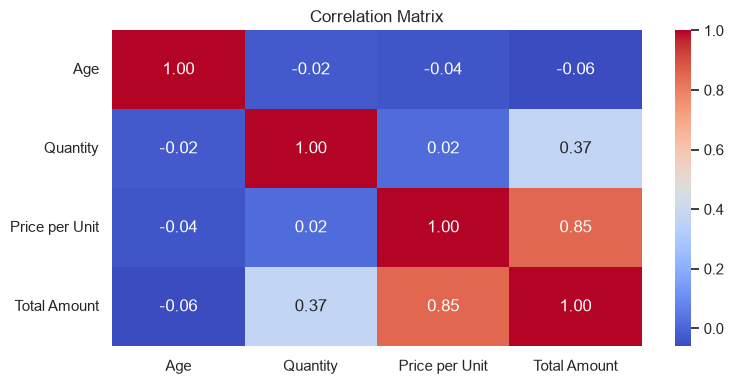

In [30]:
numeric_cols = ["Age", "Quantity", "Price per Unit", "Total Amount"]

plt.figure(figsize=(8, 4))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


**Observation:** `Price per Unit` has a strong correlation with `Total Amount`
(r = 0.85), `Quantity` is much weaker (r = 0.37). So price is really what's driving
revenue here, not how many items people buy. `Age` barely correlates with anything
(under 0.07 for everything), so age on its own doesn't predict spending.

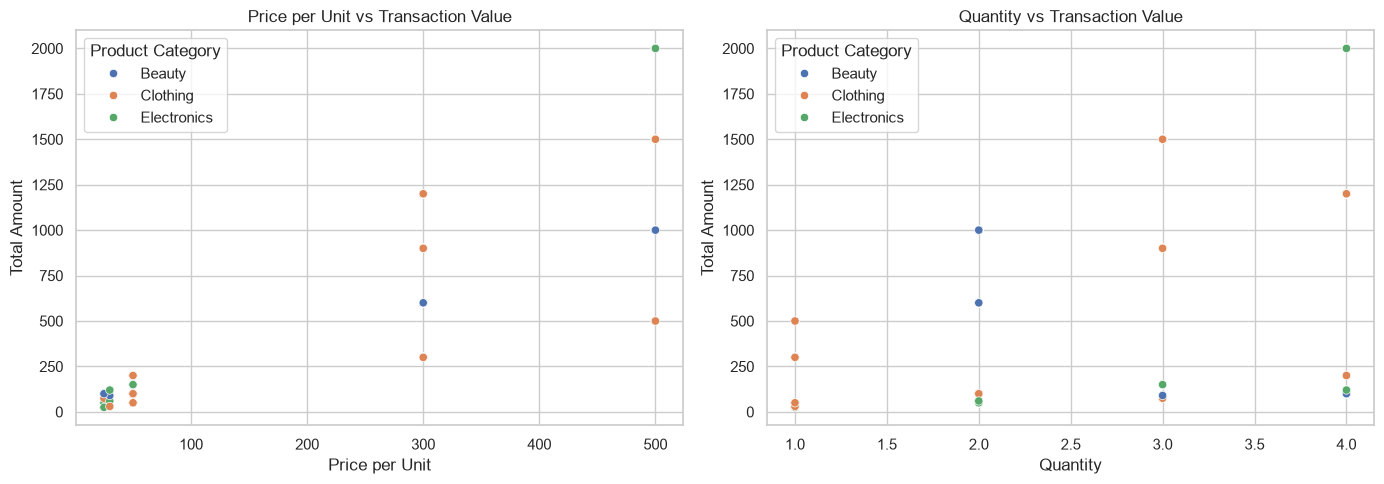

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x="Price per Unit", y="Total Amount", hue="Product Category", ax=axes[0])
axes[0].set_title("Price per Unit vs Transaction Value")

sns.scatterplot(data=df, x="Quantity", y="Total Amount", hue="Product Category", ax=axes[1])
axes[1].set_title("Quantity vs Transaction Value")

plt.tight_layout()
plt.show()


**Observation:** Worth noting these two relationships aren't fully "discovered" —
`Total Amount` is literally `Quantity × Price`, so some correlation is built in by
definition. What's more useful here is comparing how tight each pattern looks: Price vs
Total is a tight, steep line (matches the 0.85 correlation), Quantity vs Total is much more
scattered (matches the 0.37) — basically confirms price matters more than quantity.

## 7b. Additional Insight — Average Spend by Age Group × Product Category

Category-only and age-only breakdowns above both suggest fairly even, unremarkable
patterns. But neither shows whether specific *age groups* have a spending "sweet spot" in
a *specific category* — that combination is the genuinely non-obvious pattern in this
dataset.

Product Category,Beauty,Clothing,Electronics
Age_Group,,,
18–24,545.0,492.0,462.0
25–34,420.0,570.0,434.0
35–44,577.0,391.0,474.0
45–54,492.0,399.0,407.0
55–64,333.0,391.0,516.0


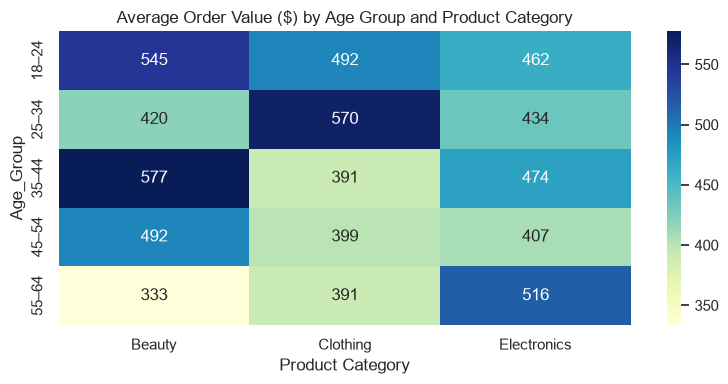

In [32]:
age_category_avg = df.pivot_table(
    values="Total Amount", index="Age_Group", columns="Product Category",
    aggfunc="mean", observed=False
)

display(age_category_avg.round(0))

plt.figure(figsize=(8, 4))
sns.heatmap(age_category_avg, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Average Order Value ($) by Age Group and Product Category")
plt.tight_layout()
plt.show()

**Observation:** This is the pattern I found most interesting. 25-34 year olds spend
the most per transaction on Clothing (\$570), 35-44 year olds spend the most on Beauty
(\$577), and 55-64 year olds — even though they have the lowest overall average spend —
actually spend the most on Electronics (\$516) out of any age group. So each age group has
its own category where it spends more, which you can't see if you only look at category
totals or age totals separately.

## 8. Key Business Metrics

In [33]:
total_revenue = df["Total Amount"].sum()
total_transactions = df["Transaction ID"].nunique()
total_units = df["Quantity"].sum()
avg_transaction = df["Total Amount"].mean()
avg_units = df["Quantity"].mean()

print(f"Total Revenue: {total_revenue:,.0f}")
print(f"Total Transactions: {total_transactions:,}")
print(f"Total Units Sold: {total_units:,}")
print(f"Average Transaction Value: {avg_transaction:,.2f}")
print(f"Average Units per Transaction: {avg_units:.2f}")

print("\nTop category by revenue:")
print(category["Revenue"].idxmax(), f"({category['Revenue'].max():,.0f})")

print("\nHighest revenue month:")
best_month = monthly.loc[monthly["Revenue"].idxmax()]
print(best_month["Date"].strftime("%B %Y"), f"({best_month['Revenue']:,.0f})")

print("\nHighest revenue age group:")
print(age_summary["Revenue"].idxmax(), f"({age_summary['Revenue'].max():,.0f})")


Total Revenue: 456,000
Total Transactions: 1,000
Total Units Sold: 2,514
Average Transaction Value: 456.00
Average Units per Transaction: 2.51

Top category by revenue:
Electronics (156,905)

Highest revenue month:
May 2023 (53,150)

Highest revenue age group:
45–54 (97,235)


**Observation:** These numbers match what came up earlier — Electronics is on top by
a small margin, May 2023 is the best month, and the highest-revenue age group is one of
the middle brackets, not the youngest or oldest.

## 9. Outlier Review

Because `Total Amount` is affected by both unit price and quantity, high-value transactions should be reviewed as business segments rather than automatically removed as statistical errors.


In [34]:
Q1 = df["Total Amount"].quantile(0.25)
Q3 = df["Total Amount"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Total Amount"] < lower) | (df["Total Amount"] > upper)]

print("Lower threshold:", lower)
print("Upper threshold:", upper)
print("Potential transaction-value outliers:", len(outliers))

display(
    outliers.sort_values("Total Amount", ascending=False)
            [["Transaction ID", "Date", "Gender", "Age", "Product Category",
              "Quantity", "Price per Unit", "Total Amount"]]
            .head(20)
)


Lower threshold: -1200.0
Upper threshold: 2160.0
Potential transaction-value outliers: 0


,Transaction ID,Date,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount


**Observation:** Using the IQR method, the upper cutoff for `Total Amount` comes out
to \$2,160 — but the highest transaction in the data is only \$2,000. So there are no
outliers at all, every transaction is within a normal range.

## 10. Key Observations

- Category performance is pretty balanced — no one category dominates.
- Gender doesn't really affect spending in this data.
- Price drives revenue way more than quantity does (0.85 vs 0.37 correlation), and age on
  its own barely matters.
- Different age groups spend more in different categories (25-34 → Clothing, 35-44 →
  Beauty, 55-64 → Electronics) — this only shows up when you cross age and category
  together, not separately.
- Monthly revenue bounces around rather than following a clear season (May high,
  September low), and there aren't any real outliers in transaction value.
- Data is clean — no missing values, no duplicates, and `Total Amount` checks out against
  `Quantity × Price per Unit`.

## 11. Business Recommendations

1. **Target promotions by age group + category combo, not just age alone.** Since 25-34
   spends more on Clothing, 35-44 on Beauty, and 55-64 on Electronics, a generic "target
   young customers" or "target older customers" campaign would miss this. Match the
   category being promoted to the age group it actually performs best with.

2. **Focus on price/premium strategy over quantity-based deals.** Price correlates with
   revenue way more than quantity does, so "buy more, save more" type offers probably
   won't move revenue as much as pushing higher-priced items or bundling toward a higher
   price point would.

3. **Look into why Beauty has fewer transactions, instead of discounting it.** Beauty has
   the highest average order value but the lowest transaction count. Discounting it would
   hurt that strong per-transaction value — better to focus on getting more people to buy
   it in the first place (samples, first-purchase offers, etc.) rather than cutting price.

4. **Don't lock in a seasonal plan around May/September yet.** The swing between best and
   worst quarter isn't huge (~24%), and this is only one year of data. I'd wait for a
   second year before committing budget to seasonal stock builds around these months.

**Limitation:** every `Customer ID` only shows up once in this dataset, so there's no way
to look at repeat purchases, retention, or loyalty from this data. That would need a
dataset that tracks the same customers across multiple orders.

### Next steps
1. Add product name/SKU, store location, discount, and cost data to get to actual
   profitability, not just revenue.
2. Build a dashboard for revenue, transactions, units sold, avg transaction value,
   category performance, and monthly trend that updates as new data comes in.
3. Once there's product-level and repeat-customer data, come back and do proper basket
   analysis and customer segmentation.
